# Random Forest

To predict credit card approval

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("input_data/random_forest_credit_card.csv")

In [3]:
df.head()

,Ind_ID,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Birthday_count,Employed_days,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members,label
0,5008827,M,Y,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,-18772.0,365243,1,0,0,0,NaN,2,1
1,5009744,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2,1
2,5009746,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,NaN,-586,1,1,1,0,NaN,2,1
3,5009749,F,Y,N,0,NaN,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2,1
4,5009752,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-13557.0,-586,1,1,1,0,NaN,2,1


In [4]:
df.label.value_counts()

0    1373
1     175
Name: label, dtype: int64

## Data Cleaning

Birthday count is the number of days a person has been born with today as day 0. So, to get age we need to divide by -365

In [5]:
df['age']=df['Birthday_count']/-365

In [6]:
df.drop('Birthday_count',axis=1,inplace=True)

In [7]:
df.head()

,Ind_ID,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Employed_days,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members,label,age
0,5008827,M,Y,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,365243,1,0,0,0,NaN,2,1,51.430137
1,5009744,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-586,1,1,1,0,NaN,2,1,37.142466
2,5009746,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-586,1,1,1,0,NaN,2,1,NaN
3,5009749,F,Y,N,0,NaN,Commercial associate,Higher education,Married,House / apartment,-586,1,1,1,0,NaN,2,1,37.142466
4,5009752,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,-586,1,1,1,0,NaN,2,1,37.142466


Employed days is the number of days a person has remained employed counting backwards from today. Positive value means the person is unemployed

In [8]:
df['Employed_days']=np.where(df['Employed_days']>0,0,df['Employed_days'])
df['employed_years']=df['Employed_days']/(-365)
df.drop('Employed_days',axis=1,inplace=True)

In [9]:
for i in df.columns:
    print(i,":",df[i].isna().sum())

Ind_ID : 0
GENDER : 7
Car_Owner : 0
Propert_Owner : 0
CHILDREN : 0
Annual_income : 23
Type_Income : 0
EDUCATION : 0
Marital_status : 0
Housing_type : 0
Mobile_phone : 0
Work_Phone : 0
Phone : 0
EMAIL_ID : 0
Type_Occupation : 488
Family_Members : 0
label : 0
age : 22
employed_years : 0


In [10]:
df.Type_Occupation.value_counts(dropna=False)

NaN                      488
Laborers                 268
Core staff               174
Managers                 136
Sales staff              122
Drivers                   86
High skill tech staff     65
Medicine staff            50
Accountants               44
Security staff            25
Cleaning staff            22
Cooking staff             21
Private service staff     17
Low-skill Laborers         9
Secretaries                9
Waiters/barmen staff       5
HR staff                   3
IT staff                   2
Realty agents              2
Name: Type_Occupation, dtype: int64

For categorical variable it is best to define a different category as Missing 

In [11]:
df['Type_Occupation']=df['Type_Occupation'].fillna('Type_Occupation_Missing')
df['GENDER']=df['GENDER'].fillna('Gender_Missing')

Now, for numerical variables, a different approach is required, so filling in the missing values with median

In [12]:
df['Annual_income']=df['Annual_income'].fillna(df['Annual_income'].median())
df['age']=df['age'].fillna(df['age'].median())

In [13]:
df.head()

,Ind_ID,GENDER,Car_Owner,Propert_Owner,CHILDREN,Annual_income,Type_Income,EDUCATION,Marital_status,Housing_type,Mobile_phone,Work_Phone,Phone,EMAIL_ID,Type_Occupation,Family_Members,label,age,employed_years
0,5008827,M,Y,Y,0,180000.0,Pensioner,Higher education,Married,House / apartment,1,0,0,0,Type_Occupation_Missing,2,1,51.430137,-0.000000
1,5009744,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,1,1,1,0,Type_Occupation_Missing,2,1,37.142466,1.605479
2,5009746,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,1,1,1,0,Type_Occupation_Missing,2,1,42.908219,1.605479
3,5009749,F,Y,N,0,166500.0,Commercial associate,Higher education,Married,House / apartment,1,1,1,0,Type_Occupation_Missing,2,1,37.142466,1.605479
4,5009752,F,Y,N,0,315000.0,Commercial associate,Higher education,Married,House / apartment,1,1,1,0,Type_Occupation_Missing,2,1,37.142466,1.605479


In [14]:
categorical_variable=df.select_dtypes(include=['object']).columns
for i in categorical_variable:
    a=df[i].value_counts()
    print(i)
    print(a)

GENDER
F                 973
M                 568
Gender_Missing      7
Name: GENDER, dtype: int64
Car_Owner
N    924
Y    624
Name: Car_Owner, dtype: int64
Propert_Owner
Y    1010
N     538
Name: Propert_Owner, dtype: int64
Type_Income
Working                 798
Commercial associate    365
Pensioner               269
State servant           116
Name: Type_Income, dtype: int64
EDUCATION
Secondary / secondary special    1031
Higher education                  426
Incomplete higher                  68
Lower secondary                    21
Academic degree                     2
Name: EDUCATION, dtype: int64
Marital_status
Married                 1049
Single / not married     227
Civil marriage           101
Separated                 96
Widow                     75
Name: Marital_status, dtype: int64
Housing_type
House / apartment      1380
With parents             80
Municipal apartment      53
Rented apartment         21
Office apartment          9
Co-op apartment           5
Name: Housin

In [15]:
df['Mobile_phone'].value_counts()

1    1548
Name: Mobile_phone, dtype: int64

Dropping mobile_phone

In [16]:
df.drop('Mobile_phone',axis=1,inplace=True)

## Data preperation

Finding the correlation between the variables and creating a correlation graph

In [17]:
df.drop('Ind_ID',axis=1,inplace=True)

In [18]:
def cat_num_split(df):
    categorical_variables = df.select_dtypes(include=['object', 'string']).columns.tolist()
    df_categorical=df[categorical_variables]
    numerical_variables = df.select_dtypes(include=['number']).columns.tolist()
    df_numerical=df[numerical_variables]
    return df_categorical,df_numerical,categorical_variables,numerical_variables

In [19]:
def corr_graph(df_numerical):
    corr=df_numerical.corr().round(2)
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
    plt.title("Correlation Heatmap")
    plt.show()

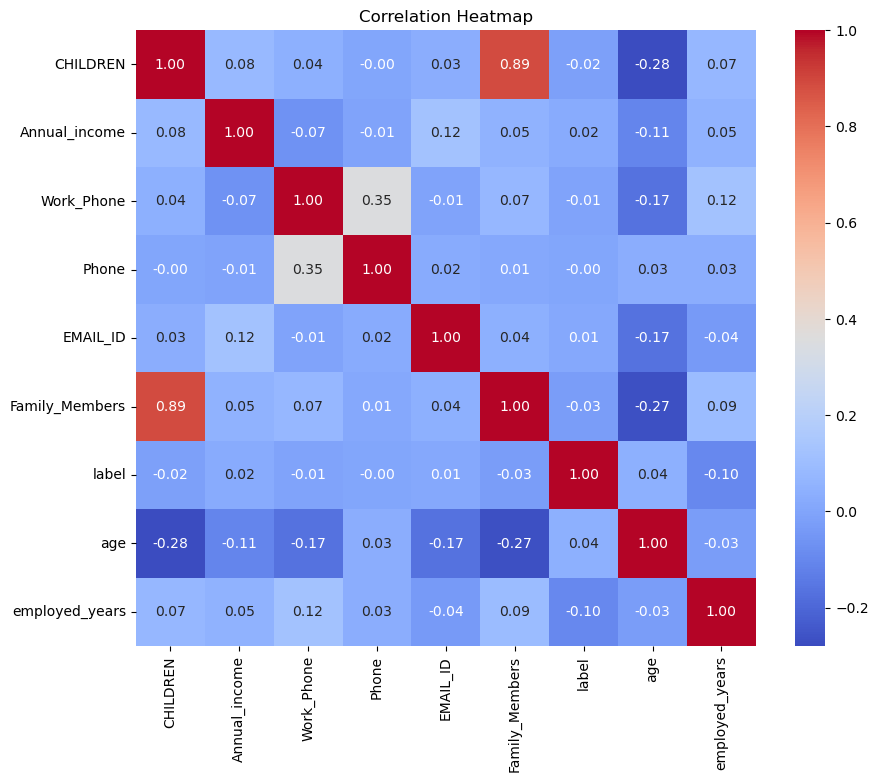

In [20]:
df_categorical,df_numerical,categorical_variables,numerical_variables=cat_num_split(df)
corr_graph(df_numerical)

Here children and family members have high correlation with each other. As children is a subset of family members, dropping the children column

In [21]:
df.drop('CHILDREN',axis=1,inplace=True)

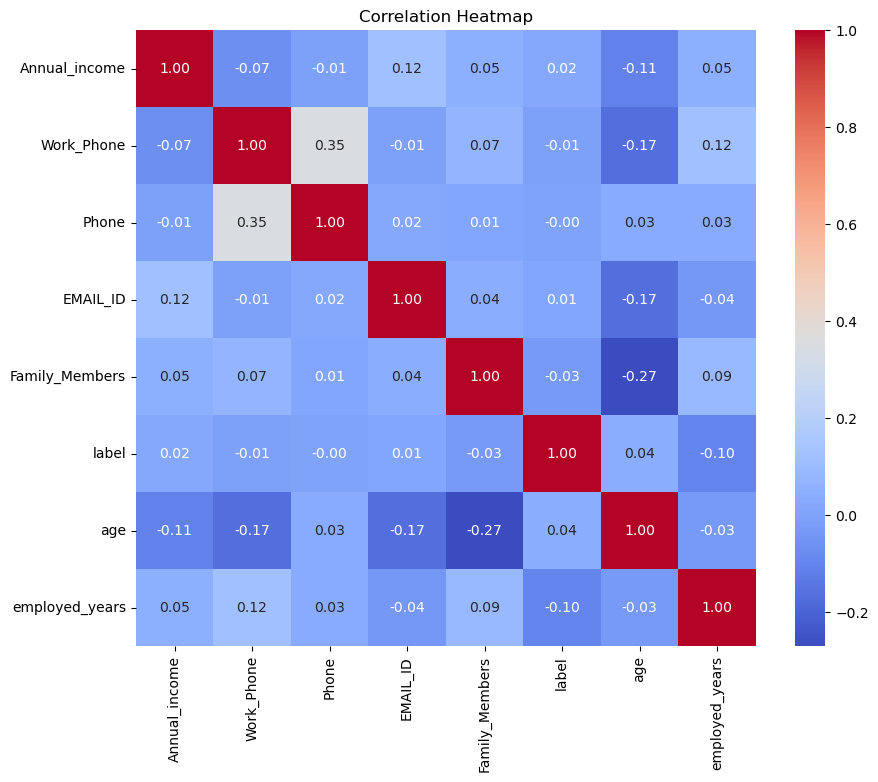

In [22]:
df_categorical,df_numerical,categorical_variables,numerical_variables=cat_num_split(df)
corr_graph(df_numerical)

This seems fine as there seems to be no multicollinearity among the variables

In [23]:
df_numerical.groupby('label').agg(['mean'])

,Annual_income,Work_Phone,Phone,EMAIL_ID,Family_Members,age,employed_years
,mean,mean,mean,mean,mean,mean,mean
label,,,,,,,
0,190049.142389,0.209031,0.309541,0.091042,2.171886,43.746943,6.301891
1,198720.000000,0.200000,0.308571,0.102857,2.080000,45.378521,4.285276


For numerical variable, plotting box plot

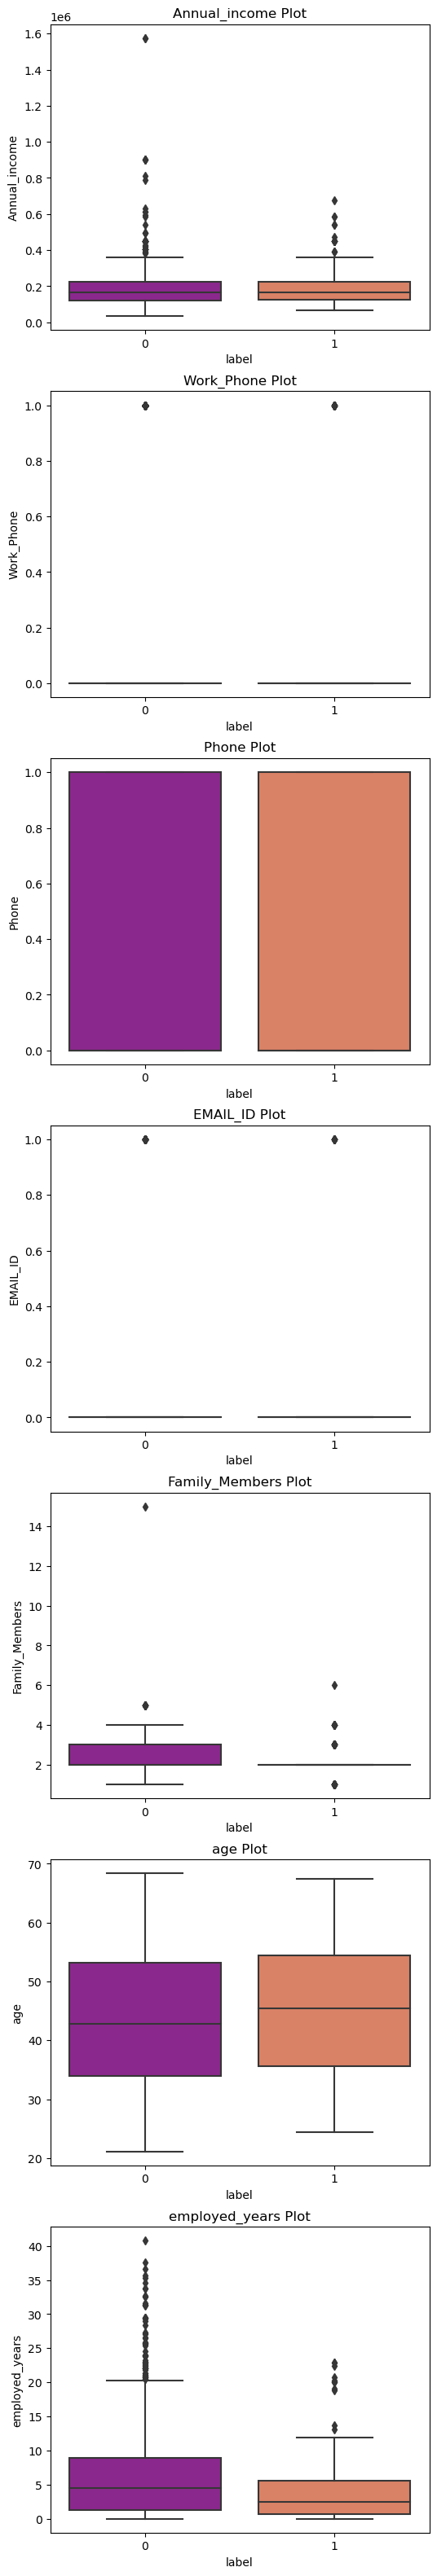

In [24]:
cols=df_numerical.columns
cols=[c for c in cols if c!='label']
l=len(cols)
plt.figure(figsize=(6,40))
for i in range(l):
    plt.subplot(l,1,i+1)
    sns.boxplot(x=df.label,y=df[cols[i]],palette=("plasma"))
    plt.title(cols[i]+' Plot')
plt.show()

## Data Scaling and Dummy Variables 

Scaling numerical Columns using min-max scaler

In [25]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
numerical_variables=[i for i in numerical_variables if i!='label' ]
df[numerical_variables]=scaler.fit_transform(df[numerical_variables])

Dummy Variables for categorical Columns

In [26]:
l=len(categorical_variables)

for i in range(l):
    temp=pd.get_dummies(df[categorical_variables[i]],drop_first=True,prefix=categorical_variables[i],prefix_sep='_')
    df=pd.concat([df,temp],axis=1)
    df.drop(categorical_variables[i],axis=1,inplace=True)
    

In [27]:
df.head()

,Annual_income,Work_Phone,Phone,EMAIL_ID,Family_Members,label,age,employed_years,GENDER_Gender_Missing,GENDER_M,...,Type_Occupation_Low-skill Laborers,Type_Occupation_Managers,Type_Occupation_Medicine staff,Type_Occupation_Private service staff,Type_Occupation_Realty agents,Type_Occupation_Sales staff,Type_Occupation_Secretaries,Type_Occupation_Security staff,Type_Occupation_Type_Occupation_Missing,Type_Occupation_Waiters/barmen staff
0,0.094891,0.0,0.0,0.0,0.071429,1,0.641900,0.000000,0,1,...,0,0,0,0,0,0,0,0,1,0
1,0.182482,1.0,1.0,0.0,0.071429,1,0.339423,0.039363,0,0,...,0,0,0,0,0,0,0,0,1,0
2,0.182482,1.0,1.0,0.0,0.071429,1,0.461487,0.039363,0,0,...,0,0,0,0,0,0,0,0,1,0
3,0.086131,1.0,1.0,0.0,0.071429,1,0.339423,0.039363,0,0,...,0,0,0,0,0,0,0,0,1,0
4,0.182482,1.0,1.0,0.0,0.071429,1,0.339423,0.039363,0,0,...,0,0,0,0,0,0,0,0,1,0


## Train test Split

In [28]:
from sklearn.model_selection import train_test_split

In [29]:
np.random.seed(20)

In [30]:
df_train,df_test=train_test_split(df,train_size=0.7,test_size=0.3,random_state=100)

In [31]:
y_train=df_train.pop('label')
x_train=df_train

In [32]:
y_test=df_test.pop('label')
x_test=df_test

## Model Building

In [33]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix,roc_auc_score, roc_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

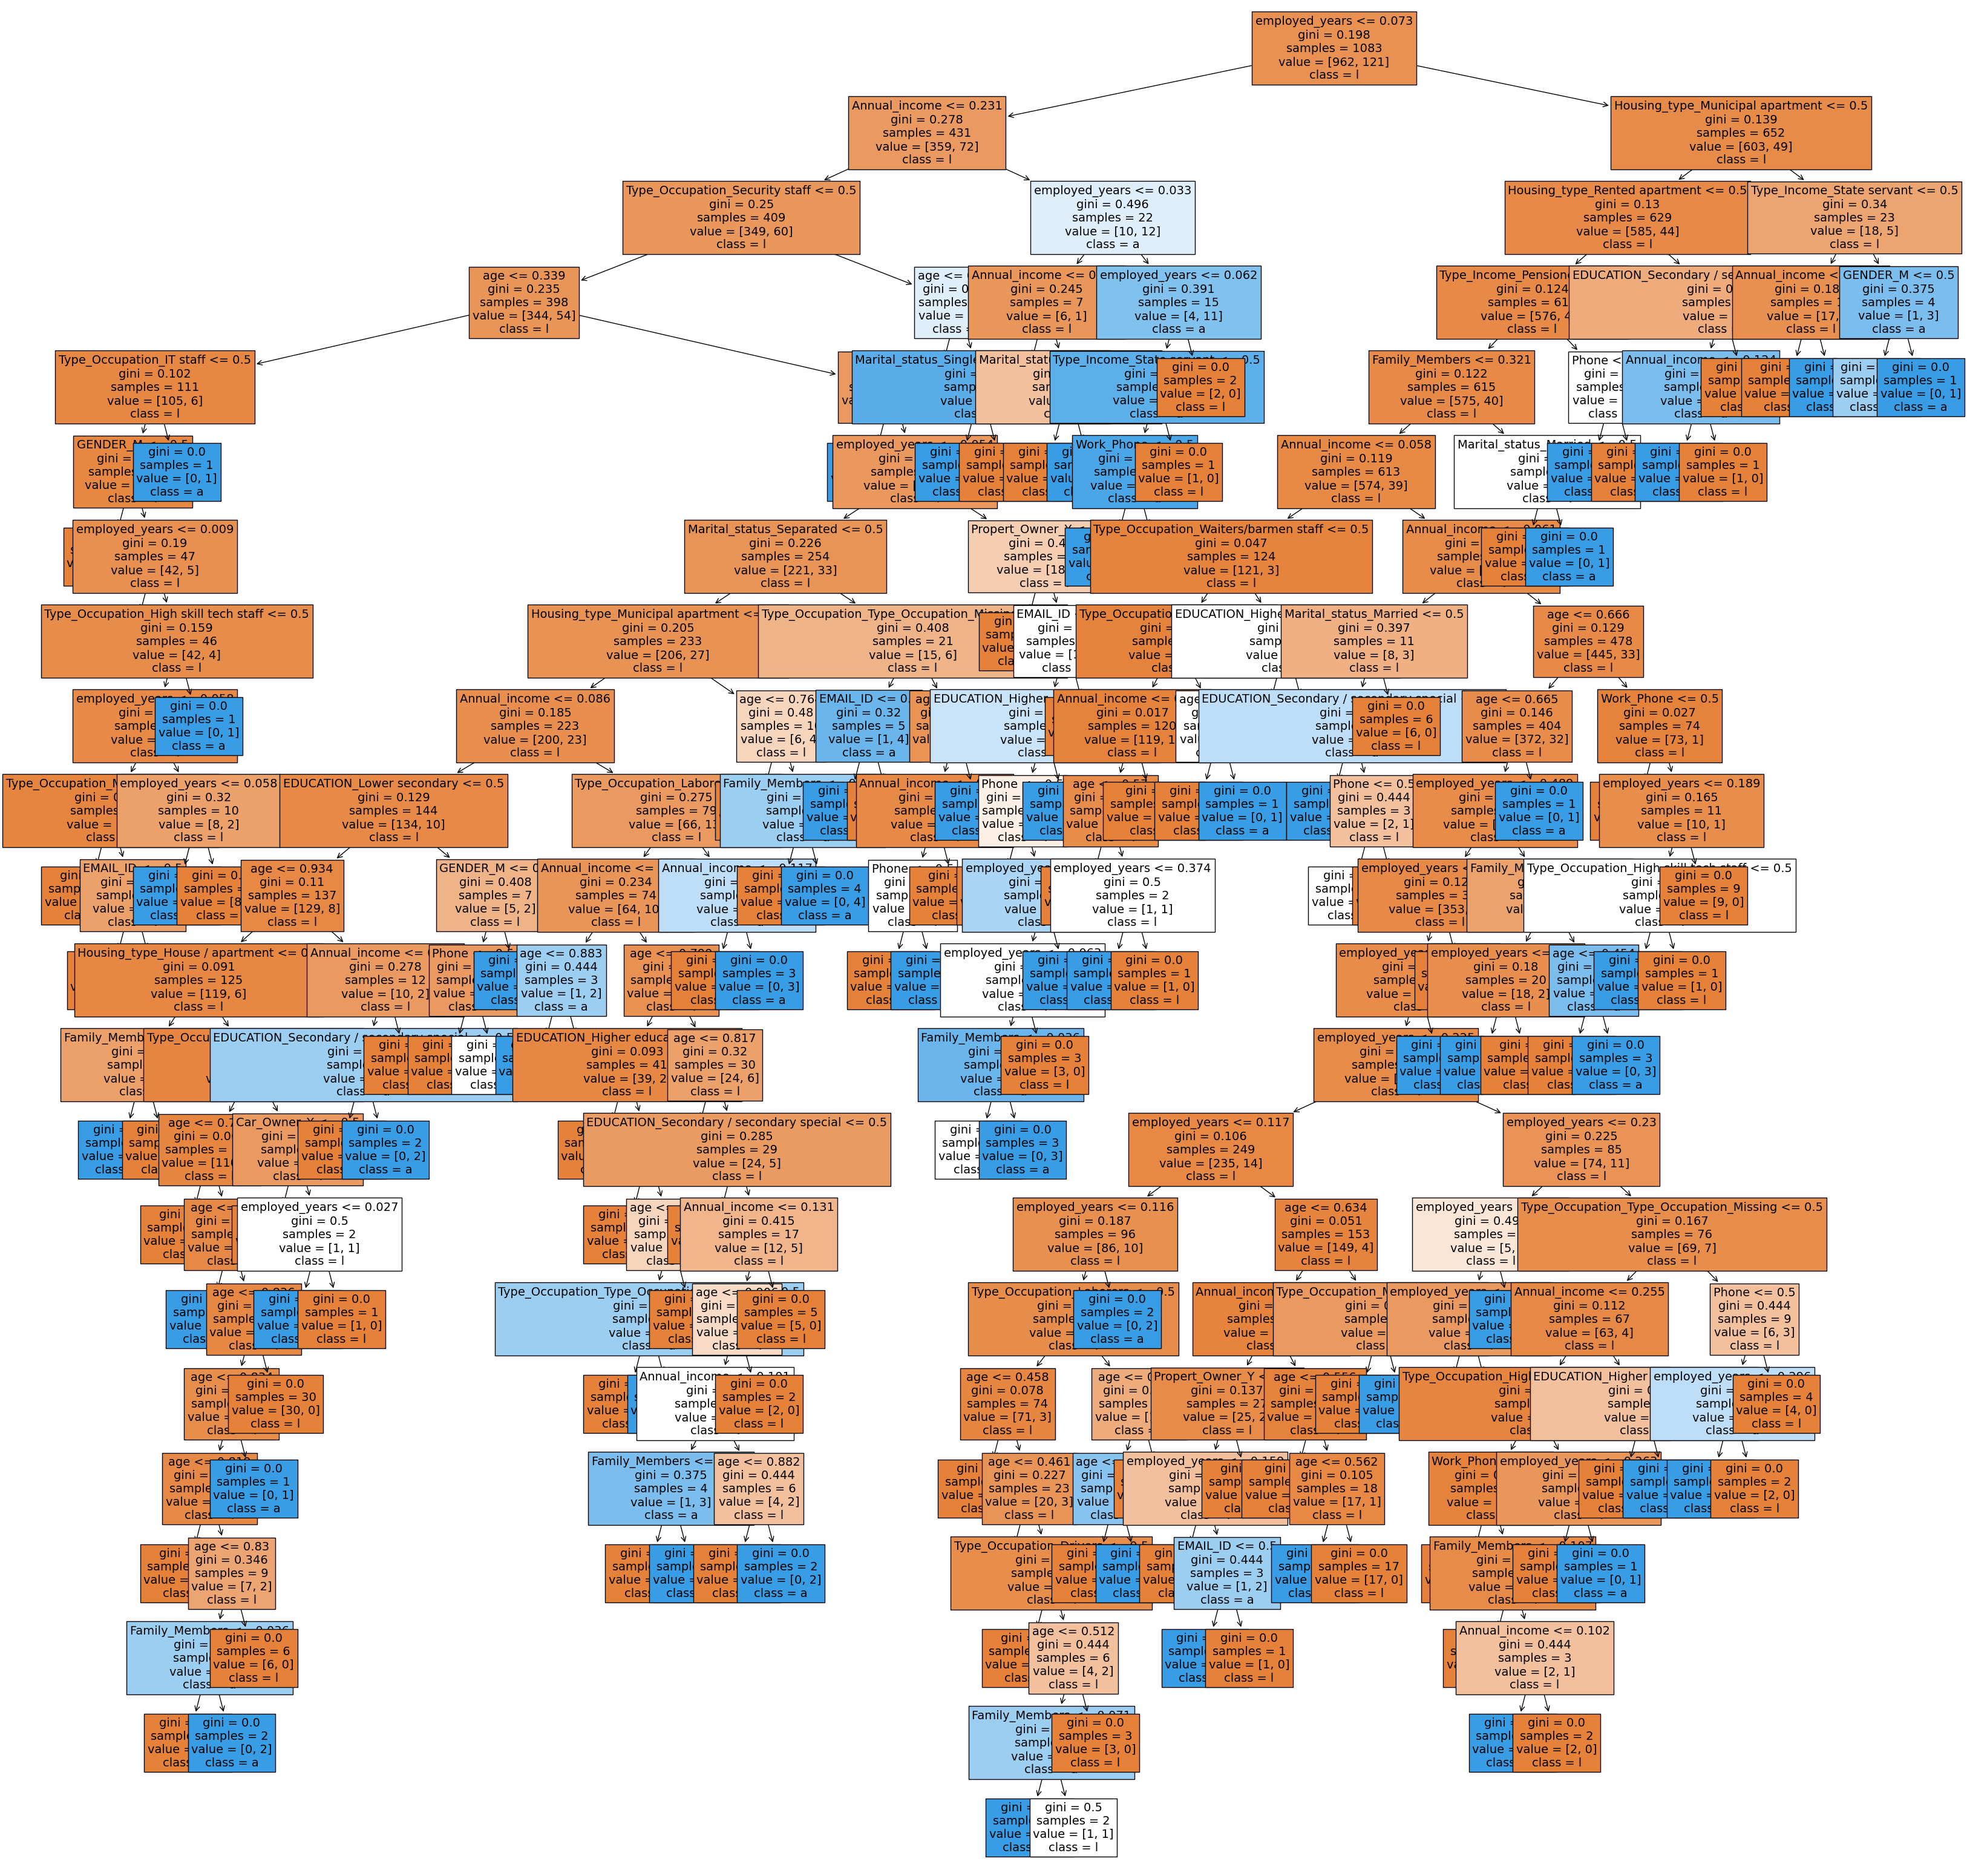

In [34]:
dt_clf=DecisionTreeClassifier(random_state=0)
dt_clf.fit(x_train,y_train)
plt.figure(figsize=(40,40))
plot_tree(dt_clf, filled=True, feature_names=x_train.columns, class_names=y_train.name,fontsize=14)
plt.show()

In [35]:
n_estimators= [int(x) for x in np.linspace(start=200,stop=2000, num=10)]
max_features=[None,'sqrt']
max_depth=[int(x) for x in np.linspace(start=2,stop=20,num=10)]
max_depth.append(None)
min_samples_split=[7,10,15]
min_samples_leaf=[3,7,9,10,14]
bootstrap=[True,False]

random_grid = {
    'n_estimators': n_estimators, 
    'max_features': max_features,
    'max_depth': max_depth, 
    'min_samples_split': min_samples_split,
    'min_samples_leaf': min_samples_leaf, 
    'bootstrap': bootstrap
}

1. n_estimators: Number of trees to be built in the forest
1. max_features: Maximum number of features considered at each split.
1. max_depth: Maximum levels a tree can grow.
1. min_samples_split: Minimum samples required to split an internal node.
1. min_samples_leaf: Minimum samples required to be at a leaf node.
1. bootstrap: Whether samples are drawn with replacement when building trees.

In [36]:
rf_clf=RandomForestClassifier(random_state=100)

rf_cv=RandomizedSearchCV(estimator=rf_clf,
                         scoring='roc_auc',
                         param_distributions=random_grid, 
                         n_iter=50,
                         cv=5,
                         random_state=100,
                         n_jobs=-1
                        )

rf_cv.fit(x_train,y_train)
rf_best_params=rf_cv.best_params_

###### n_iter: Number of random hyperparameter combinations to try from the given search space.
<br>Example: If your random_grid has 500 possible combinations and you set n_iter=50, RandomizedSearchCV will test only 50 of them (randomly chosen), whereas GridSearchCV would try all 500.

In [37]:
rv_clf=RandomForestClassifier(**rf_best_params)
rv_clf.fit(x_train,y_train)

RandomForestClassifier(max_features=None, min_samples_leaf=3,
                       min_samples_split=10, n_estimators=1200)

In [38]:
y_train_pred=rv_clf.predict(x_train)
y_train_pred_proba=rv_clf.predict_proba(x_train)[:,1]

y_test_pred=rv_clf.predict(x_test)
y_test_pred_proba=rv_clf.predict_proba(x_test)[:,1]

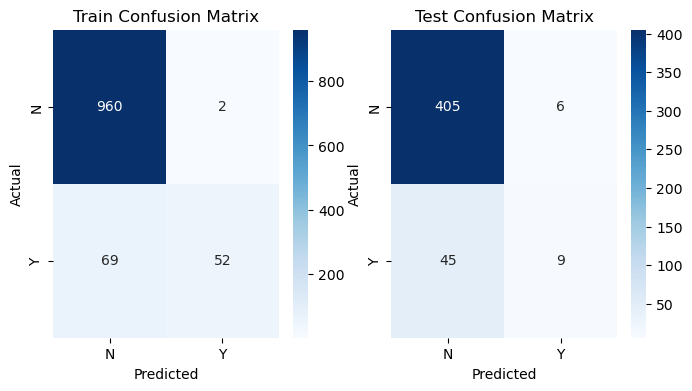

In [39]:
confusion_matrix_train=confusion_matrix(y_train,y_train_pred)
confusion_matrix_test=confusion_matrix(y_test,y_test_pred)

plt.figure(figsize=(8, 4))

plt.subplot(1,2,1)
sns.heatmap(confusion_matrix_train, annot=True, fmt='d', cmap='Blues', xticklabels=['N', 'Y'], yticklabels=['N', 'Y'])
plt.title('Train Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')

plt.subplot(1,2,2)
sns.heatmap(confusion_matrix_test, annot=True, fmt='d', cmap='Blues', xticklabels=['N', 'Y'], yticklabels=['N', 'Y'])
plt.title('Test Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')

plt.show()

In [40]:
print('Train Metrices')
print("Accuracy :", accuracy_score(y_train, y_train_pred))
print("Precision:", precision_score(y_train, y_train_pred))
print("Recall   :", recall_score(y_train, y_train_pred))
print("F1 Score :", f1_score(y_train, y_train_pred))
print('')
print('Test Metrices')
print("Accuracy :", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall   :", recall_score(y_test, y_test_pred))
print("F1 Score :", f1_score(y_test, y_test_pred))

Train Metrices
Accuracy : 0.9344413665743305
Precision: 0.9629629629629629
Recall   : 0.4297520661157025
F1 Score : 0.5942857142857143

Test Metrices
Accuracy : 0.8903225806451613
Precision: 0.6
Recall   : 0.16666666666666666
F1 Score : 0.2608695652173913


### Feature Importance

In [41]:
feature_names=x_train.columns
importances = rf_cv.best_estimator_.feature_importances_
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Sort the dataframe by importance
importance_df = importance_df.sort_values('Importance', ascending=False)

# Print the feature importances
print(importance_df)

                                    Feature  Importance
6                            employed_years    0.235649
5                                       age    0.233091
0                             Annual_income    0.182941
4                            Family_Members    0.039107
23         Housing_type_Municipal apartment    0.026306
42           Type_Occupation_Security staff    0.023596
8                                  GENDER_M    0.021595
9                               Car_Owner_Y    0.020799
34                 Type_Occupation_Laborers    0.018480
1                                Work_Phone    0.015692
10                          Propert_Owner_Y    0.014688
17  EDUCATION_Secondary / secondary special    0.014295
43  Type_Occupation_Type_Occupation_Missing    0.013657
2                                     Phone    0.013427
13                      Type_Income_Working    0.013358
14               EDUCATION_Higher education    0.013349
20      Marital_status_Single / not married    0

Summary:
1. The random forest model was built to predict the credit card approval for people 
1. The model is able to predict the negative values better than the positive values
1. The model achieves high accuracy of 89%, making it particularly useful in scenarios where overall correctness is prioritized, even if not all positive cases are captured